In [22]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt 

# Fitting Bell and Gonzalez data to competition model

In [56]:
# original model
def model1(x, theta):
    return 1 - np.exp(-theta[0] * x)

# model with competition
def model2(x, theta):
    return 1 - np.exp(-theta[0] * x/(1+theta[1]*x) )

# negative log likelihood of data given model and parameters
def neg_log_lik(model, theta, x, y, N):
    # enforce theta > 0
    if theta[0] <= 0:
        return np.inf
    
    p = model(x,theta) 
    p = np.clip(p, 1e-12, 1-1e-12) # for numerical stability
    
    ll = y * np.log(p) + (N - y) * np.log(1 - p) #log likelihood (binomial)
    return -np.sum(ll)

# maximum likelihood parameter values
def MLE_fit(Ndata_range, PRdata_range, model, theta0, bounds, N): 
    x = np.array(Ndata_range)
    y = np.array([PR*N for PR in PRdata_range])
    N = np.array([N for xi in x])
    
    res = minimize(
        lambda t: neg_log_lik(model, t, x, y, N),
        x0=theta0,
        bounds=bounds
    )
    theta = res.x
    
    PRpred_range = np.array([model(N, theta) for N in Ndata_range])
    ss_res = np.sum((PRdata_range - PRpred_range)**2)
    ss_tot = np.sum((PRdata_range - np.mean(PRdata_range))**2)
    r2 = 1 - ss_res/ss_tot
    
    return theta, r2, neg_log_lik(model, theta, x, y, N)

## Experiment 1

In [75]:
# approximating Bell and Gonzalez data by eye (from left panel of fig 3 in Martin et al 2013 Phil Trans B)
Ndata_range = [5, 30, 300, 1e3, 1e4, 2e4] #initial pop sizes
PRdata_range = [0.01, 0.125, 0.7, 1, 1, 1] #rescue probabilities
N = 60 #number of replicates for each pop size

# fit model 1
theta0 = [0.005]
bounds = [(1e-9,None)]
theta1, r2_1, nll1 = MLE_fit(Ndata_range, PRdata_range, model1, theta0, bounds, N)

# fit model 2
theta0 = [0.005, 0.01]
bounds = [(1e-9,None),(0,None)]
theta2, r2_2, nll2 = MLE_fit(Ndata_range, PRdata_range, model2, theta0, bounds, N)

theta1, theta2

(array([0.00433456]), array([0.00433456, 0.        ]))

In [76]:
# AICs
AIC1 = np.log(len(Ndata_range)) + 2*nll1
AIC2 = 2*np.log(len(Ndata_range)) + 2*nll2

# probability data from model 2 rather than model 1
ratio1 = np.exp((min(AIC1,AIC2)-AIC1)/2)
ratio2 = np.exp((min(AIC1,AIC2)-AIC2)/2)
prob2 = ratio2/(ratio1+ratio2)

prob2

np.float64(0.2898979485551466)

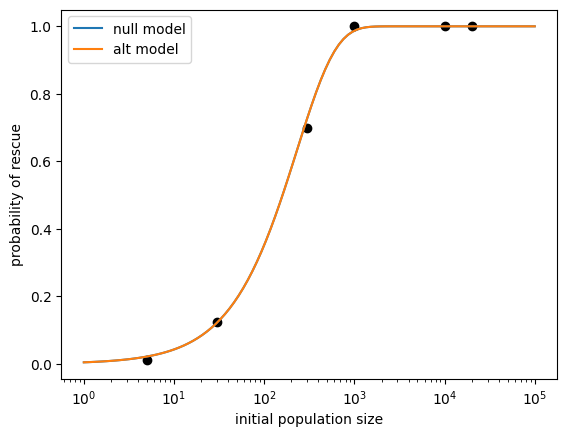

In [77]:
# data
plt.scatter(Ndata_range, PRdata_range, color='k')

# models
xs = np.logspace(0,5,100)
y1s = [model1(x,theta1) for x in xs] #model 1
plt.plot(xs, y1s, label='null model')
y2s = [model2(x,theta2) for x in xs] #model 2
plt.plot(xs, y2s, label='alt model')

plt.legend()
plt.xscale('log')
plt.xlabel('initial population size')
plt.ylabel('probability of rescue')

plt.show()

## Experiment 2

In [78]:
# approximating Bell and Gonzalez data by eye (from right panel of fig 3 in Martin et al 2013 Phil Trans B)
Ndata_range = [5, 30, 300, 2e3, 1e4, 2e4, 1e6] #initial pop sizes
PRdata_range = [0.01, 0, 0.05, 0.15, 0.7, 0.9, 1] #rescue probabilities
N = 60 #number of replicates for each pop size

# fit model 1
theta0 = [0.00005]
bounds = [(1e-9,None)]
theta1, r2_1, nll1 = MLE_fit(Ndata_range, PRdata_range, model1, theta0, bounds, N)

# fit model 2
theta0 = [0.00005, 0.01]
bounds = [(1e-9,None),(0,None)]
theta2, r2_2, nll2 = MLE_fit(Ndata_range, PRdata_range, model2, theta0, bounds, N)

theta1, theta2

(array([0.00011411]), array([1.15518325e-04, 1.80470402e-06]))

In [79]:
# AICs
AIC1 = np.log(len(Ndata_range)) + 2*nll1
AIC2 = 2*np.log(len(Ndata_range)) + 2*nll2

# probability data from model 2 rather than model 1
ratio1 = np.exp((min(AIC1,AIC2)-AIC1)/2)
ratio2 = np.exp((min(AIC1,AIC2)-AIC2)/2)
prob2 = ratio2/(ratio1+ratio2)

prob2

np.float64(0.26557087125980455)

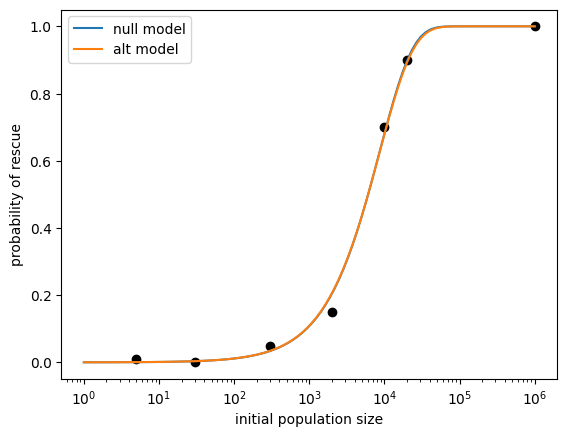

In [81]:
# data
plt.scatter(Ndata_range, PRdata_range, color='k')

# models
xs = np.logspace(0,6,100)
y1s = [model1(x,theta1) for x in xs] #model 1
plt.plot(xs, y1s, label='null model')
y2s = [model2(x,theta2) for x in xs] #model 2
plt.plot(xs, y2s, label='alt model')

plt.legend()
plt.xscale('log')
plt.xlabel('initial population size')
plt.ylabel('probability of rescue')

plt.show()